# Car brand from the front

Predict a car's brand from a photo of its front, using the DVM-CAR `confirmed_fronts` images.

## 1. Clean the data and build the image index

Files stay where they are. This section writes `data/index.csv`, one row per image we keep, and every later step reads from it.

Steps:
1. Read brand, model, year, colour and advert from every file name
2. Merge sub-brands into their parent brand (Abarth → Fiat, DS → Citroen)
3. Remove images that can't be opened
4. Remove exact duplicate images
5. Keep only brands with at least 200 images

In [1]:
from pathlib import Path
import hashlib

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = Path("data")
IMAGES_DIR = DATA_DIR / "confirmed_fronts"
INDEX_CSV = DATA_DIR / "index.csv"
MODELS_DIR = Path("models")

MIN_IMAGES_PER_BRAND = 200

# Sub-brands that share their parent brand's front design
BRAND_MERGES = {"Abarth": "Fiat", "DS": "Citroen"}

### 1.1 Read every file name

Files are stored as `confirmed_fronts/<Brand>/<Year>/<file>.jpg`, and each file name holds 7 fields separated by `$$`:

`Land Rover$$Discovery$$2017$$Silver$$47_6$$130$$image_5.jpg` → brand, model, year, colour, model ID, advert number, image name.

The brand label comes from the folder. The advert ID (model ID + advert number) is what we'll split on later, so photos of the same car never end up in both training and test.

In [2]:
rows = []
bad_names = []
brand_mismatches = []

for path in sorted(IMAGES_DIR.rglob("*.jpg")):
    parts = path.name.split("$$")
    if len(parts) != 7:
        bad_names.append(path)
        continue

    name_brand, model, year, color, genmodel_id, adv_number, _ = parts
    folder_brand = path.relative_to(IMAGES_DIR).parts[0]
    if name_brand != folder_brand:
        brand_mismatches.append(path)

    rows.append({
        "path": path.as_posix(),
        "brand": folder_brand,
        "model": model,
        "year": int(year),
        "color": color,
        "genmodel_id": genmodel_id,
        "advert_id": f"{genmodel_id}$${adv_number}",
    })

df = pd.DataFrame(rows)
print(f"{len(df):,} images from {df['brand'].nunique()} brands")
print(f"{len(bad_names)} files with an unexpected name (skipped)")
print(f"{len(brand_mismatches)} files whose folder brand differs from the brand in the file name")
df.head()

61,827 images from 63 brands
0 files with an unexpected name (skipped)
0 files whose folder brand differs from the brand in the file name


,path,brand,model,year,color,genmodel_id,advert_id
0,data/confirmed_fronts/Abarth/2013/Abarth$$595$...,Abarth,595,2013,Black,2_4,2_4$$100
1,data/confirmed_fronts/Abarth/2013/Abarth$$595$...,Abarth,595,2013,Black,2_4,2_4$$191
2,data/confirmed_fronts/Abarth/2013/Abarth$$595$...,Abarth,595,2013,Black,2_4,2_4$$229
3,data/confirmed_fronts/Abarth/2013/Abarth$$595$...,Abarth,595,2013,Black,2_4,2_4$$236
4,data/confirmed_fronts/Abarth/2013/Abarth$$595$...,Abarth,595,2013,Black,2_4,2_4$$287


### 1.2 Merge sub-brands

In [3]:
for sub_brand, parent in BRAND_MERGES.items():
    print(f"{sub_brand} → {parent}: {(df['brand'] == sub_brand).sum()} images")

df["brand"] = df["brand"].replace(BRAND_MERGES)
print(f"{df['brand'].nunique()} brands after merging")

Abarth → Fiat: 130 images
DS → Citroen: 11 images
61 brands after merging


### 1.3 Remove images that can't be opened

Every image is fully decoded, so truncated files are caught too. This takes a minute or two.

In [4]:
def image_info(path):
    """Return (width, height, colour mode) if the image decodes, otherwise None."""
    try:
        with Image.open(path) as img:
            img.load()
            return (*img.size, img.mode)
    except Exception:
        return None


info = df["path"].map(image_info)
broken = info.isna()
print(f"{broken.sum()} unreadable images removed")
df = df[~broken].copy()

print("\nImage size and colour mode:")
print(info[~broken].value_counts().to_string())

0 unreadable images removed

Image size and colour mode:
path
(300, 300, RGB)    61827


### 1.4 Remove exact duplicates

Car adverts often reuse the same photo. A duplicate that ends up in both training and test inflates the score, so we keep one copy of each image.

Some dealers also reuse one stock photo in adverts for other brands. For example, a single Kia Picanto photo appears 37 times, filed under Audi, Citroen, Fiat, Kia and Toyota. When the same image appears under more than one brand, its label can't be trusted, so every copy is dropped.

In [5]:
df["md5"] = df["path"].map(lambda p: hashlib.md5(Path(p).read_bytes()).hexdigest())

brands_per_image = df.groupby("md5")["brand"].nunique()
conflicting = brands_per_image[brands_per_image > 1].index

n_before = len(df)
df = df[~df["md5"].isin(conflicting)]
print(f"{n_before - len(df)} images removed because the same file appears under different brands")

n_before = len(df)
df = df.drop_duplicates(subset="md5", keep="first")
print(f"{n_before - len(df)} duplicate copies removed")

125 images removed because the same file appears under different brands
500 duplicate copies removed


### 1.5 Keep brands with at least 200 images

This comes last so the counts reflect the cleaned data.

In [6]:
counts = df["brand"].value_counts()
kept_brands = counts[counts >= MIN_IMAGES_PER_BRAND].index
dropped = counts[counts < MIN_IMAGES_PER_BRAND]

print(f"Dropping {len(dropped)} brands ({dropped.sum():,} images):")
print(", ".join(f"{brand} ({n})" for brand, n in dropped.items()))

df = df[df["brand"].isin(kept_brands)].reset_index(drop=True)
print(f"\nKeeping {df['brand'].nunique()} brands, {len(df):,} images")

Dropping 28 brands (1,076 images):
Infiniti (171), Chrysler (142), Ferrari (109), Ssangyong (96), Isuzu (61), Tesla (59), Smart (52), Lamborghini (50), Dodge (49), McLaren (43), MG (42), Daihatsu (41), Saab (36), Aston Martin (31), Rolls-Royce (31), Lotus (12), Rover (11), Great Wall (10), Proton (6), Daewoo (5), Corvette (4), Noble (4), Bugatti (3), Cadillac (2), Opel (2), Perodua (2), MEV (1), Zenos (1)

Keeping 33 brands, 60,126 images


### 1.6 Save the index

In [7]:
df = df.drop(columns="md5")
df.to_csv(INDEX_CSV, index=False)
print(f"Saved {len(df):,} rows to {INDEX_CSV}")

Saved 60,126 rows to data/index.csv


### 1.7 Check the result

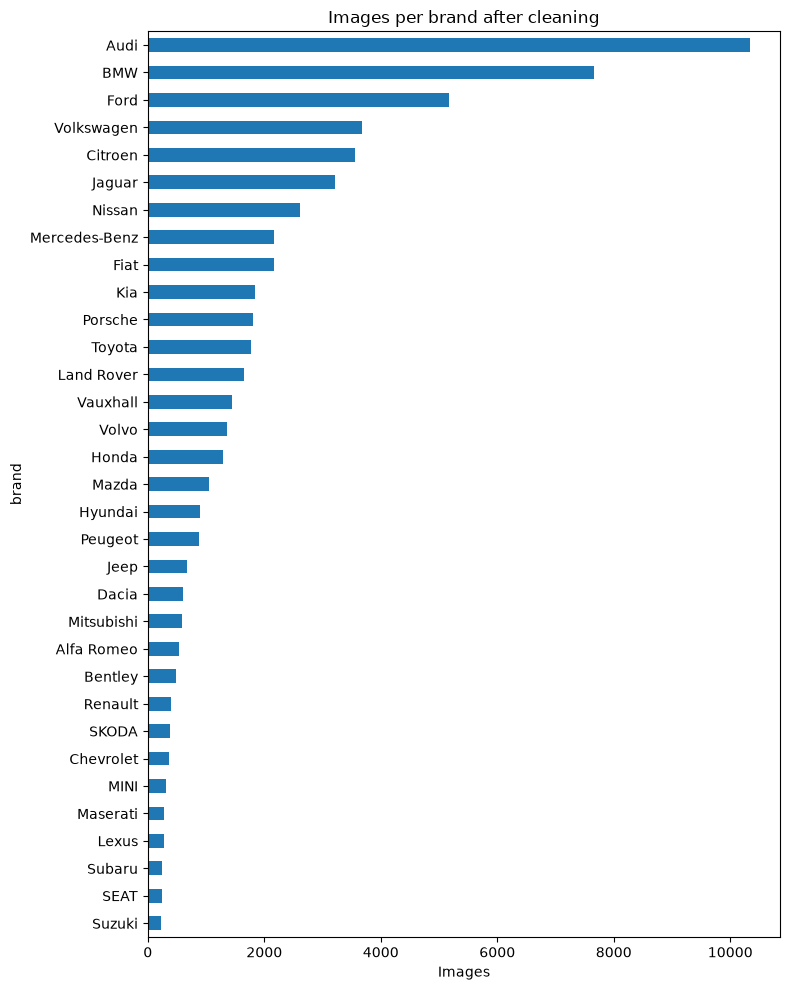

In [8]:
ax = df["brand"].value_counts().sort_values().plot.barh(figsize=(8, 10))
ax.set_xlabel("Images")
ax.set_title("Images per brand after cleaning")
plt.tight_layout()
plt.show()

One random photo per brand. Look for anything that isn't a car front.

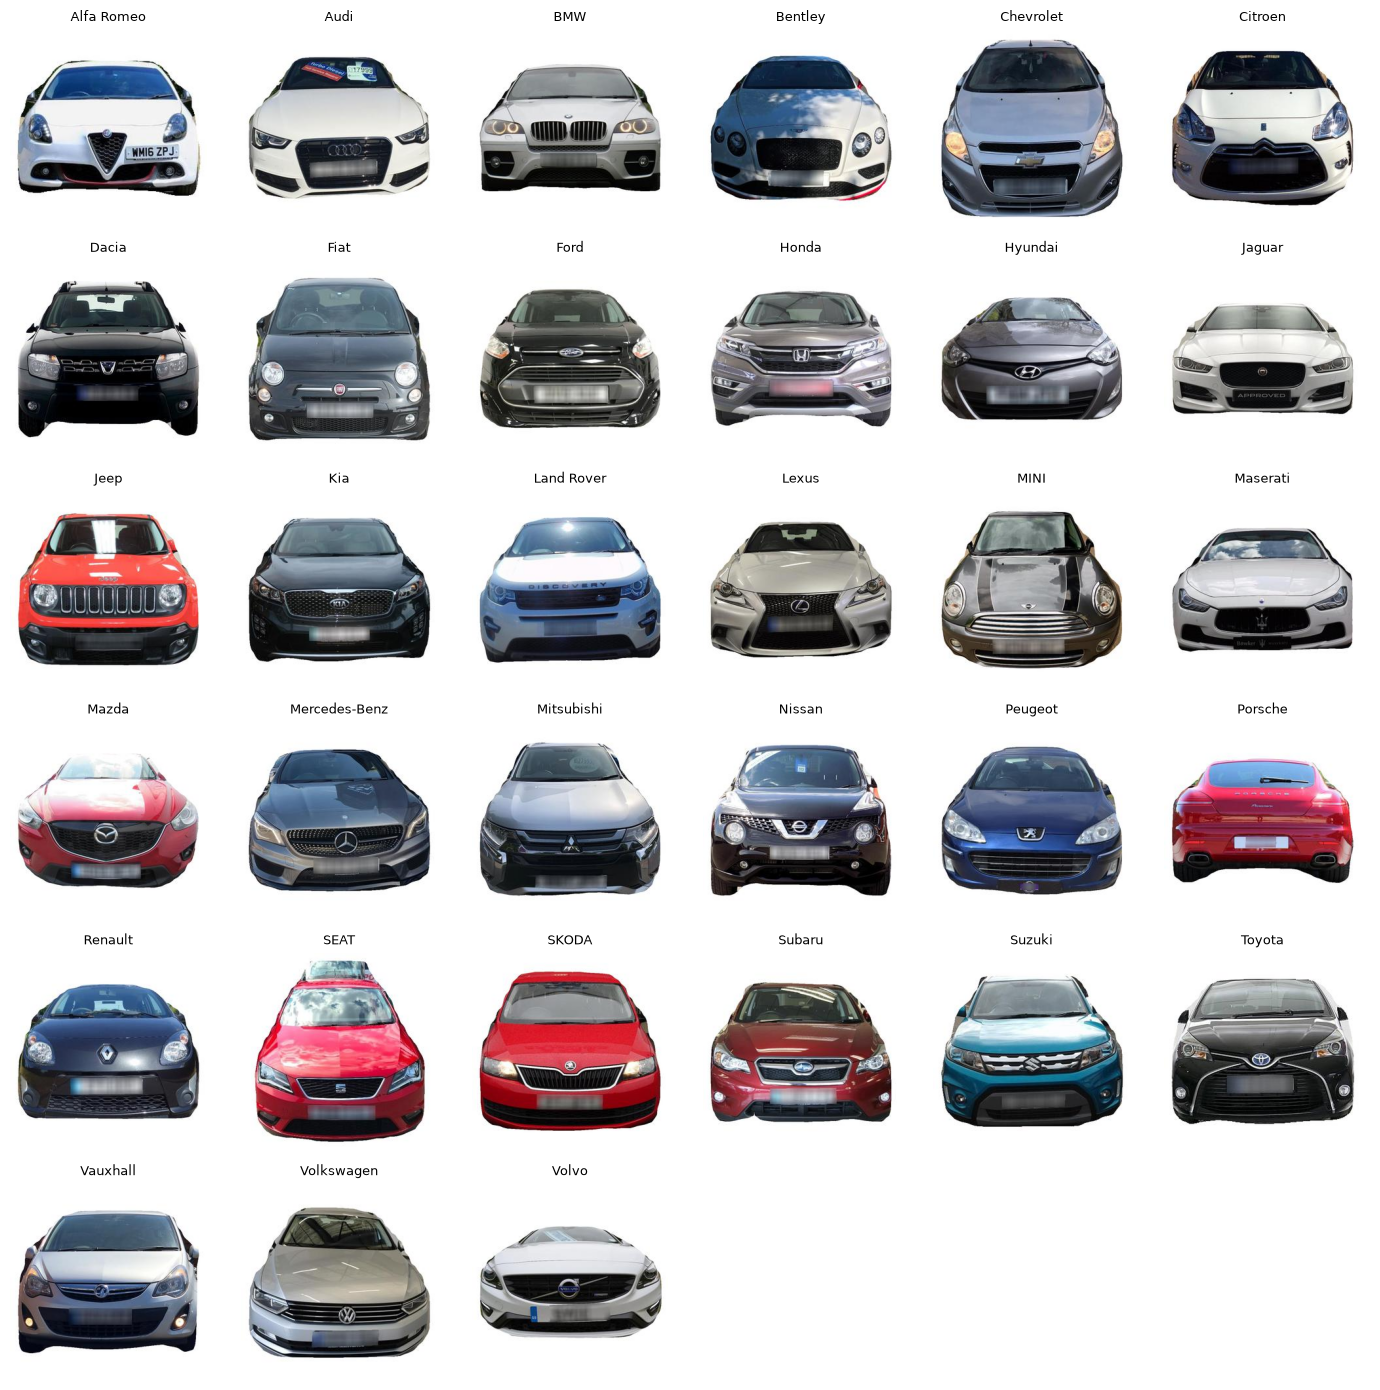

In [9]:
samples = df.groupby("brand").sample(1, random_state=0)

fig, axes = plt.subplots(6, 6, figsize=(14, 14))
for ax in axes.flat:
    ax.axis("off")
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    ax.imshow(Image.open(row["path"]))
    ax.set_title(row["brand"], fontsize=9)
plt.tight_layout()
plt.show()

## 2. Split into train, validation and test

Three sets, 80 / 10 / 10:
- **train**: the images the model learns from
- **validation**: checked after every epoch, to tune training and keep the best version of the model
- **test**: left untouched until the very end, for one final, honest score

The split is made per advert, not per image, so photos of the same car never land in two sets. It's also made within each brand, so even the smallest brands get their share of validation and test images.

Section 2 reads `data/index.csv`, so after a kernel restart you only need to run the first cell of section 1.

In [10]:
import numpy as np

SEED = 42
VAL_FRACTION = 0.1
TEST_FRACTION = 0.1

df = pd.read_csv(INDEX_CSV)

# One row per advert with its brand, in random order
adverts = df.groupby("advert_id")["brand"].first().sample(frac=1, random_state=SEED).to_frame()

# Within each brand, the first 10% of adverts go to test, the next 10% to validation, the rest to train
position = adverts.groupby("brand").cumcount() / adverts.groupby("brand")["brand"].transform("size")
adverts["split"] = np.select(
    [position < TEST_FRACTION, position < TEST_FRACTION + VAL_FRACTION],
    ["test", "val"],
    default="train",
)

df["split"] = df["advert_id"].map(adverts["split"])
print(df["split"].value_counts().to_string())

split
train    48150
val       5994
test      5982


### 2.1 Check the split

No advert should appear in two sets, and every brand should have images in all three.

In [11]:
adverts_in_several_splits = (df.groupby("advert_id")["split"].nunique() > 1).sum()
print(f"{adverts_in_several_splits} adverts appear in more than one split")

per_brand = pd.crosstab(df["brand"], df["split"])[["train", "val", "test"]]
print("\nFewest images for a single brand in each split:")
print(per_brand.min().to_string())

0 adverts appear in more than one split

Fewest images for a single brand in each split:
split
train    186
val       24
test      23


## 3. Load the images with `tf.data`

`tf.data` reads images from disk batch by batch while the model trains, so the 60,000 images never have to fit in memory at once. Each image is decoded and shrunk from 300×300 to 128×128 pixels. Smaller images train much faster, and 128 px is enough for a first model.

Each brand becomes a number from 0 to 32 (its position in alphabetical order), because that's what the model predicts.

TensorFlow should list one GPU: the Metal plugin runs training on the M5's graphics chip, about 3× faster than the CPU.

In [12]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hide TensorFlow's startup messages

import tensorflow as tf
import keras
from keras import layers

print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

IMAGE_SIZE = 128
BATCH_SIZE = 64

class_names = sorted(df["brand"].unique())
df["label"] = df["brand"].map({brand: i for i, brand in enumerate(class_names)})


def load_image(path, label, image_size=IMAGE_SIZE):
    image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    image = tf.image.resize(image, (image_size, image_size))
    return image, label


def make_dataset(split, image_size=IMAGE_SIZE, shuffle=False):
    part = df[df["split"] == split]
    ds = tf.data.Dataset.from_tensor_slices((part["path"].values, part["label"].values))
    if shuffle:
        ds = ds.shuffle(len(part), seed=SEED)
    ds = ds.map(lambda path, label: load_image(path, label, image_size), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset("train", shuffle=True)
val_ds = make_dataset("val")
test_ds = make_dataset("test")

TensorFlow 2.18.1 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1790606043.770962 10558875 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790606043.771000 10558875 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### 3.1 Look at one batch

A batch is 64 images with their labels. This checks that images and brands still match after loading.

Images: (64, 128, 128, 3) <dtype: 'float32'> | Labels: (64,)


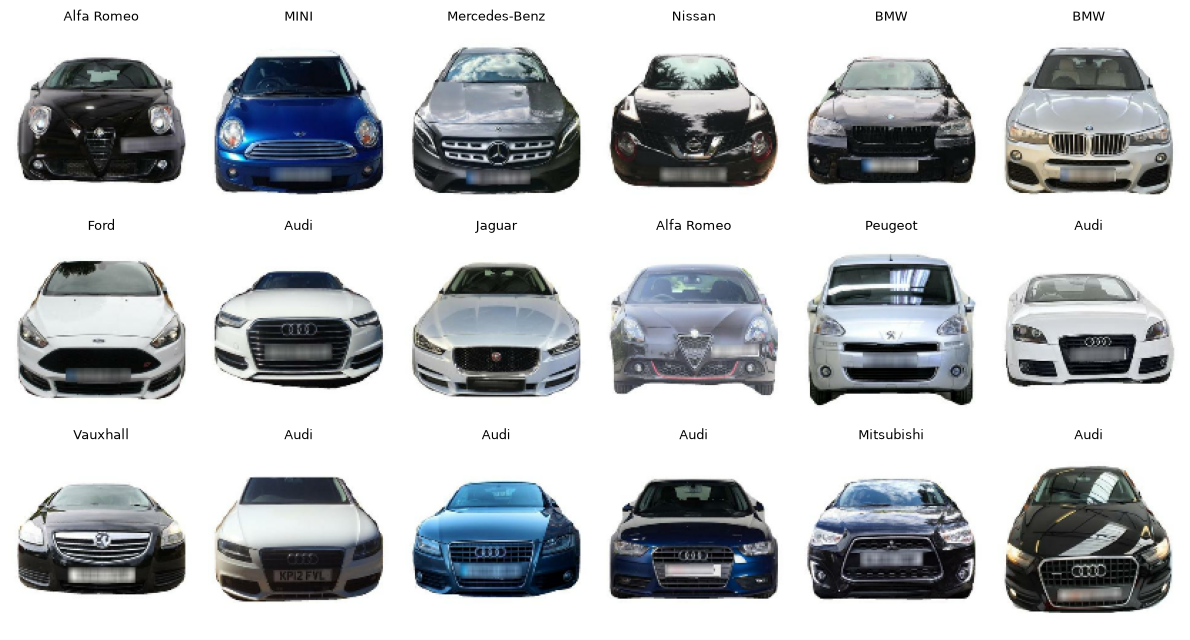

In [13]:
images, labels = next(iter(train_ds))
print("Images:", images.shape, images.dtype, "| Labels:", labels.shape)

fig, axes = plt.subplots(3, 6, figsize=(12, 6.5))
for ax, image, label in zip(axes.flat, images, labels):
    ax.imshow(image.numpy().astype("uint8"))
    ax.set_title(class_names[int(label)], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. First model: a small CNN from scratch

A convolutional neural network (CNN) scans the image with small 3×3 filters. Early layers pick up edges and colours; deeper layers combine them into grilles, headlights and badges. This one starts from random weights and learns everything from our 48,000 training images.

### 4.1 Balance the brands

Audi has about 45 times more training images than Suzuki. Left alone, the model would learn that "Audi" is a safe guess. Class weights make each mistake on a rare brand count more, so every brand weighs the same in total:

weight = training images / (number of brands × images of this brand)

In [14]:
train_counts = df.loc[df["split"] == "train", "label"].value_counts()
class_weight = {
    int(label): train_counts.sum() / (len(class_names) * count)
    for label, count in train_counts.items()
}

for brand in ["Audi", "BMW", "Peugeot", "Suzuki"]:
    print(f"{brand}: {class_weight[class_names.index(brand)]:.2f}")

Audi: 0.18
BMW: 0.24
Peugeot: 2.09
Suzuki: 7.84


### 4.2 Augmentation

Every time the model sees a training image, it gets a slightly altered copy: shifted, zoomed, rotated a little, with different contrast and brightness. It can't memorise individual photos, so it has to learn what each brand actually looks like. These layers only change images during training; at prediction time they pass images through untouched.

We don't flip images left to right: that would mirror the badge and any lettering (KIA, MINI, the Ford script), which never happens on a real car.

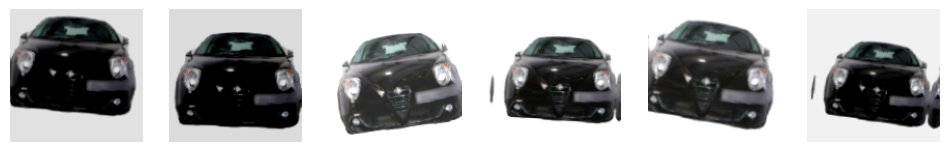

In [15]:
augment = keras.Sequential([
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.15),
    layers.RandomRotation(0.03),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="augment")

# One training image, augmented 6 times
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
for ax in axes:
    ax.imshow(augment(images[:1], training=True)[0].numpy().astype("uint8"))
    ax.axis("off")
plt.show()

### 4.3 Build the model

Five blocks, each made of:
- **Conv2D**: learns a set of 3×3 filters (32 in the first block, doubling up to 512)
- **BatchNormalization**: keeps values in a stable range, so training is faster and steadier
- **ReLU**: keeps positive signals and zeroes the rest
- **MaxPooling2D**: halves the width and height, keeping the strongest signal in each 2×2 patch

The image shrinks from 128×128 to 4×4 while the number of filters grows. **GlobalAveragePooling2D** then averages each of the 512 filters into one number, **Dropout** switches off 30% of them at random during training (another guard against memorising), and the final **Dense** layer outputs one score per brand.

In [16]:
def conv_block(filters):
    return [
        layers.Conv2D(filters, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),
    ]


model = keras.Sequential([
    keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    augment,
    layers.Rescaling(1 / 255),  # pixel values from 0–255 to 0–1
    *conv_block(32),
    *conv_block(64),
    *conv_block(128),
    *conv_block(256),
    *conv_block(512),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names)),
], name="small_cnn")

model.summary()

Model: "small_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augment (Sequential)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,588,481 (6.06 MB)

 Trainable params: 1,586,497 (6.05 MB)

 Non-trainable params: 1,984 (7.75 KB)

### 4.4 Train

- **Adam** updates the weights after every batch; a learning rate of 0.001 is its usual starting point.
- The **loss** measures how low the score of the true brand is compared to the others. `from_logits=True` because the last layer outputs raw scores, not probabilities.
- After each epoch (one pass over all training images), the model is scored on the validation set. Three callbacks watch the validation loss:
  - `ModelCheckpoint` saves the best model so far to `models/small_cnn.keras`
  - `ReduceLROnPlateau` divides the learning rate by about 3 when there's no improvement for 3 epochs
  - `EarlyStopping` stops after 6 epochs without improvement and restores the best weights

An epoch takes about 2½ minutes on the GPU. Training stops after 40 epochs at most (about 1½ hours), and early stopping will usually end it sooner. Validation accuracy is often low and jumpy for the first few epochs; that's normal.

**Training runs only once.** At the end, the model and its history are saved in `models/`. When `models/small_cnn_history.csv` exists, this cell loads them instead of training again.

In [17]:
SMALL_CNN_PATH = MODELS_DIR / "small_cnn.keras"
SMALL_CNN_HISTORY = MODELS_DIR / "small_cnn_history.csv"
EPOCHS = 40

if SMALL_CNN_HISTORY.exists():
    print(f"Already trained, loading {SMALL_CNN_PATH}")
    model = keras.models.load_model(SMALL_CNN_PATH)
    curves = pd.read_csv(SMALL_CNN_HISTORY)
else:
    MODELS_DIR.mkdir(exist_ok=True)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )

    callbacks = [
        keras.callbacks.ModelCheckpoint(SMALL_CNN_PATH, monitor="val_loss", save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weight,
        callbacks=callbacks,
    )

    model.save(SMALL_CNN_PATH)
    curves = pd.DataFrame(history.history)
    curves.to_csv(SMALL_CNN_HISTORY, index=False)
    print(f"Saved {SMALL_CNN_PATH} and {SMALL_CNN_HISTORY}")

Epoch 1/40


/Users/hugo/Documents/Car_Model_recognition/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


753/753 ━━━━━━━━━━━━━━━━━━━━ 169s 222ms/step - accuracy: 0.1448 - loss: 3.1047 - val_accuracy: 0.0973 - val_loss: 3.9915 - learning_rate: 0.0010
Epoch 2/40
753/753 ━━━━━━━━━━━━━━━━━━━━ 185s 246ms/step - accuracy: 0.5374 - loss: 1.7190 - val_accuracy: 0.3836 - val_loss: 2.9852 - learning_rate: 0.0010
Epoch 3/40
753/753 ━━━━━━━━━━━━━━━━━━━━ 188s 249ms/step - accuracy: 0.7515 - loss: 0.9433 - val_accuracy: 0.7701 - val_loss: 0.8454 - learning_rate: 0.0010
Epoch 4/40
753/753 ━━━━━━━━━━━━━━━━━━━━ 185s 245ms/step - accuracy: 0.8423 - loss: 0.5856 - val_accuracy: 0.7409 - val_loss: 0.9007 - learning_rate: 0.0010
Epoch 5/40
753/753 ━━━━━━━━━━━━━━━━━━━━ 176s 233ms/step - accuracy: 0.8854 - loss: 0.4234 - val_accuracy: 0.8500 - val_loss: 0.6270 - learning_rate: 0.0010
Epoch 6/40
753/753 ━━━━━━━━━━━━━━━━━━━━ 163s 217ms/step - accuracy: 0.9061 - loss: 0.3409 - val_accuracy: 0.8475 - val_loss: 0.5743 - learning_rate: 0.0010
Epoch 7/40
753/753 ━━━━━━━━━━━━━━━━━━━━ 377s 502ms/step - accuracy: 0.9195 

### 4.5 Learning curves

If the training loss keeps falling while the validation loss climbs, the model is overfitting: memorising training photos instead of learning brands.

The training accuracy counts rare brands more (because of the class weights) and the validation accuracy doesn't, so the two accuracy curves aren't exactly comparable. The per-brand scores below are the fair measure.

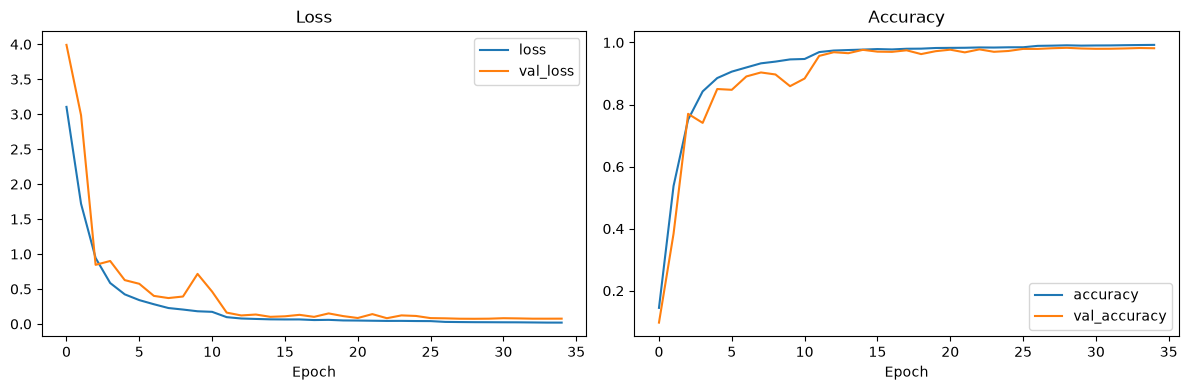

In [18]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
curves[["loss", "val_loss"]].plot(ax=ax_loss, title="Loss")
curves[["accuracy", "val_accuracy"]].plot(ax=ax_acc, title="Accuracy")
for ax in (ax_loss, ax_acc):
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

### 4.6 Score per brand on the validation set

Overall accuracy is dominated by the big brands: Audi alone is about 17% of the validation images. **Balanced accuracy** is the average of the per-brand accuracies, so Suzuki counts as much as Audi.

The test set stays untouched until we've picked our final model.

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step
Accuracy: 98.3%
Balanced accuracy: 97.5%


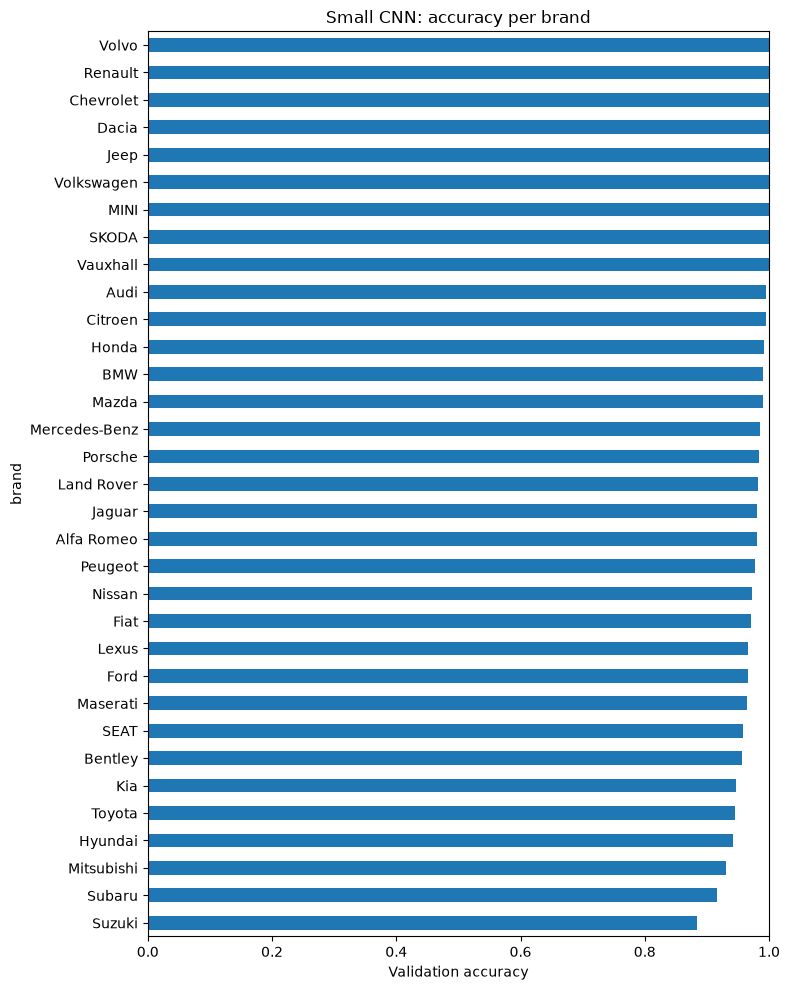

In [19]:
val = df[df["split"] == "val"].copy()
val["predicted"] = model.predict(val_ds).argmax(axis=1)
val["correct"] = val["predicted"] == val["label"]

per_brand_accuracy = val.groupby("brand")["correct"].mean().sort_values()
print(f"Accuracy: {val['correct'].mean():.1%}")
print(f"Balanced accuracy: {per_brand_accuracy.mean():.1%}")

ax = per_brand_accuracy.plot.barh(figsize=(8, 10))
ax.set_xlim(0, 1)
ax.set_xlabel("Validation accuracy")
ax.set_title("Small CNN: accuracy per brand")
plt.tight_layout()
plt.show()

### 4.7 Most common mistakes

Which brands get mistaken for which? Similar-looking pairs (same group, shared platforms, similar grilles) are expected.

In [21]:
val["predicted_brand"] = [class_names[i] for i in val["predicted"]]
mistakes = val[~val["correct"]].groupby(["brand", "predicted_brand"]).size()
print(mistakes.sort_values(ascending=False).head(15).to_string())

brand       predicted_brand
Ford        Hyundai            4
            Mitsubishi         3
Kia         Hyundai            3
Toyota      Volkswagen         2
Porsche     Jaguar             2
Ford        Subaru             2
            Kia                2
            Citroen            2
Mitsubishi  Toyota             2
Fiat        Volkswagen         2
Nissan      Mitsubishi         2
Toyota      Citroen            2
Audi        Mitsubishi         2
Toyota      Nissan             2
Mazda       Hyundai            1


## 5. Second model: fine-tune a pretrained EfficientNetB0

Instead of starting from random weights, we start from **EfficientNetB0**, a CNN already trained on ImageNet (1.3 million photos in 1,000 categories, including several kinds of cars). Its layers already detect edges, textures, wheels, grilles and lettering. We remove its last layer (the 1,000 ImageNet categories) and put our own 33-brand layer on top. This is called **transfer learning**.

Training happens in two phases:
1. **Train only the new layer.** The pretrained part is frozen. A brand-new layer starts random, and its large early errors would wreck the pretrained weights if they could change.
2. **Fine-tune the top of the network** with a 10× lower learning rate, so the pretrained features adapt gently to car fronts.

Before running this section after a kernel restart, run the first cell of section 1, section 2, the first code cell of section 3, and 4.1 and 4.2 (class weights and augmentation).

**Training runs only once.** The model and its history are saved in `models/`. When `models/efficientnet_b0_history.csv` exists, 5.3 and 5.4 skip training and 5.5 loads the saved model.

### 5.1 Load the images at 224×224

EfficientNetB0 was trained on 224×224 images, so we use that size instead of 128. It rescales pixel values itself, so the images stay in 0–255.

In [8]:
PRETRAINED_IMAGE_SIZE = 224

train_ds_224 = make_dataset("train", PRETRAINED_IMAGE_SIZE, shuffle=True)
val_ds_224 = make_dataset("val", PRETRAINED_IMAGE_SIZE)

### 5.2 Build the model

Same augmentation as the small CNN, then the pretrained EfficientNet, then pooling, dropout and our 33-brand layer. `show_trainable=True` in the summary shows which parts will learn: only the new Dense layer for now.

`training=False` keeps EfficientNet's BatchNormalization layers in prediction mode, even after we unfreeze it. Otherwise they'd recompute their statistics from our batches and undo part of the pretraining.

In [9]:
EFFNET_PATH = MODELS_DIR / "efficientnet_b0.keras"
EFFNET_HISTORY = MODELS_DIR / "efficientnet_b0_history.csv"

base = keras.applications.EfficientNetB0(
    include_top=False,  # without its original 1,000-category layer
    weights="imagenet",
    input_shape=(PRETRAINED_IMAGE_SIZE, PRETRAINED_IMAGE_SIZE, 3),
)
base.trainable = False

# The same augmentation layers as the small CNN, in a new block: the old one is fixed to 128×128 inputs
augment_224 = keras.Sequential(augment.layers, name="augment_224")

inputs = keras.Input(shape=(PRETRAINED_IMAGE_SIZE, PRETRAINED_IMAGE_SIZE, 3))
x = augment_224(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names))(x)
effnet = keras.Model(inputs, outputs, name="efficientnet_b0")

effnet.summary(show_trainable=True)

Model: "efficientnet_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ augment_224 (Sequential)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetb0 (Functional) │ (None, 7, 7, 1280)    │  4,049,571 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 33)            │     42,273 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 4,091,844 (15.61 MB)

 Trainable params: 42,273 (165.13 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 5.3 Phase 1: train the new layer

Only 42,000 weights learn here (1,280 EfficientNet features × 33 brands), so this is quick: 3 epochs of about 3½ minutes each.

In [10]:
HEAD_EPOCHS = 3

if EFFNET_HISTORY.exists():
    print(f"Already trained, skipping: 5.5 loads {EFFNET_PATH}")
else:
    effnet.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    history_head = effnet.fit(
        train_ds_224,
        validation_data=val_ds_224,
        epochs=HEAD_EPOCHS,
        class_weight=class_weight,
    )

Epoch 1/3


/Users/hugo/Documents/Car_Model_recognition/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


753/753 ━━━━━━━━━━━━━━━━━━━━ 258s 339ms/step - accuracy: 0.6419 - loss: 1.8610 - val_accuracy: 0.8190 - val_loss: 0.9426

Epoch 2/3

753/753 ━━━━━━━━━━━━━━━━━━━━ 271s 359ms/step - accuracy: 0.7822 - loss: 1.1172 - val_accuracy: 0.8455 - val_loss: 0.7423

Epoch 3/3

753/753 ━━━━━━━━━━━━━━━━━━━━ 268s 356ms/step - accuracy: 0.8083 - loss: 0.9278 - val_accuracy: 0.8817 - val_loss: 0.5732


### 5.4 Phase 2: fine-tune the top blocks

EfficientNetB0 is made of 7 blocks. The early ones detect generic edges and textures, which are fine as they are; the later ones combine them into objects, and those are worth adapting to car fronts. We unfreeze blocks 5 to 7 (3.7 of its 4 million weights). Unfreezing everything would take 30 minutes per epoch on the M5, against 8 for blocks 5 to 7, for little gain.

After changing what's trainable, the model has to be compiled again for the change to take effect. The learning rate drops to 0.0001 instead of 0.001. The same three callbacks as for the small CNN watch the validation loss, with shorter patience because each epoch takes longer. Each epoch takes about 8 minutes, so 20 epochs at most is under 3 hours, and early stopping usually ends it sooner.

At the end, the model and the full history of both phases are saved to `models/`.

In [11]:
FINE_TUNE_EPOCHS = 20
FINE_TUNE_FROM = "block5a"  # first layer of block 5

if EFFNET_HISTORY.exists():
    print(f"Already trained, skipping: 5.5 loads {EFFNET_PATH}")
else:
    first_unfrozen = next(i for i, layer in enumerate(base.layers) if layer.name.startswith(FINE_TUNE_FROM))
    for i, layer in enumerate(base.layers):
        layer.trainable = i >= first_unfrozen

    effnet.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )

    callbacks = [
        keras.callbacks.ModelCheckpoint(EFFNET_PATH, monitor="val_loss", save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ]

    history_fine = effnet.fit(
        train_ds_224,
        validation_data=val_ds_224,
        initial_epoch=HEAD_EPOCHS,  # continue the epoch count from phase 1
        epochs=HEAD_EPOCHS + FINE_TUNE_EPOCHS,
        class_weight=class_weight,
        callbacks=callbacks,
    )

    effnet.save(EFFNET_PATH)
    both_phases = pd.concat([pd.DataFrame(history_head.history), pd.DataFrame(history_fine.history)])
    both_phases.to_csv(EFFNET_HISTORY, index=False)
    print(f"Saved {EFFNET_PATH} and {EFFNET_HISTORY}")

Epoch 4/23

753/753 ━━━━━━━━━━━━━━━━━━━━ 548s 713ms/step - accuracy: 0.8528 - loss: 0.6404 - val_accuracy: 0.9648 - val_loss: 0.1375 - learning_rate: 1.0000e-04

Epoch 5/23

753/753 ━━━━━━━━━━━━━━━━━━━━ 547s 725ms/step - accuracy: 0.9500 - loss: 0.2004 - val_accuracy: 0.9748 - val_loss: 0.0945 - learning_rate: 1.0000e-04

Epoch 6/23

753/753 ━━━━━━━━━━━━━━━━━━━━ 523s 693ms/step - accuracy: 0.9658 - loss: 0.1302 - val_accuracy: 0.9808 - val_loss: 0.0699 - learning_rate: 1.0000e-04

Epoch 7/23

753/753 ━━━━━━━━━━━━━━━━━━━━ 523s 693ms/step - accuracy: 0.9735 - loss: 0.0963 - val_accuracy: 0.9837 - val_loss: 0.0617 - learning_rate: 1.0000e-04

Epoch 8/23

753/753 ━━━━━━━━━━━━━━━━━━━━ 532s 706ms/step - accuracy: 0.9777 - loss: 0.0773 - val_accuracy: 0.9852 - val_loss: 0.0579 - learning_rate: 1.0000e-04

Epoch 9/23

753/753 ━━━━━━━━━━━━━━━━━━━━ 541s 716ms/step - accuracy: 0.9799 - loss: 0.0699 - val_accuracy: 0.9845 - val_loss: 0.0555 - learning_rate: 1.0000e-04

Epoch 10/23

753/753 ━━━━━━━

### 5.5 Load the trained model

Loads the saved model and its training history. This is the cell that makes retraining unnecessary.

In [12]:
effnet = keras.models.load_model(EFFNET_PATH)
effnet_curves = pd.read_csv(EFFNET_HISTORY)
print(f"Loaded {effnet.name}, trained for {len(effnet_curves)} epochs")

Loaded efficientnet_b0, trained for 23 epochs


### 5.6 Learning curves

The dotted line marks where fine-tuning starts.

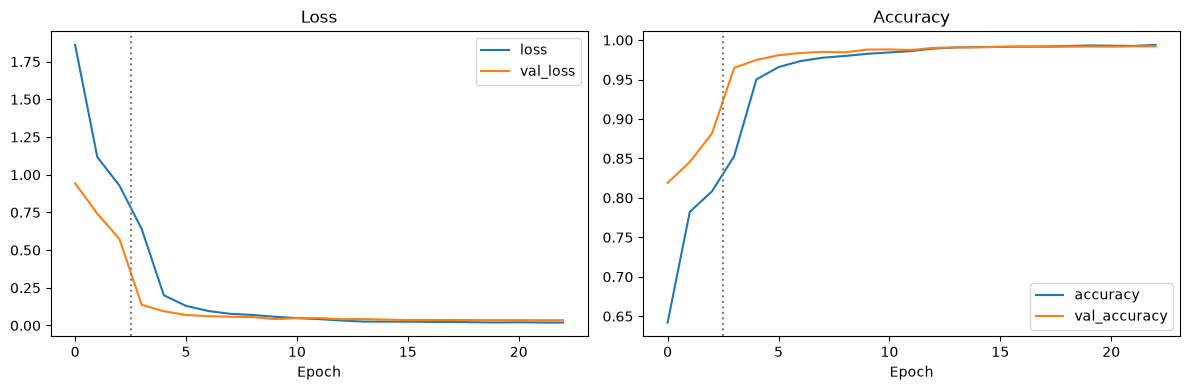

In [13]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
effnet_curves[["loss", "val_loss"]].plot(ax=ax_loss, title="Loss")
effnet_curves[["accuracy", "val_accuracy"]].plot(ax=ax_acc, title="Accuracy")
for ax in (ax_loss, ax_acc):
    ax.axvline(HEAD_EPOCHS - 0.5, color="gray", linestyle=":")
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## 6. Pick the final model and score it on the test set

### 6.1 Compare both models on the validation set

Both models are loaded from `models/`, so this section works without retraining anything. The one with the higher **balanced accuracy** becomes the final model.

               accuracy balanced accuracy
Small CNN         98.3%             97.5%
EfficientNetB0    99.2%             98.6%


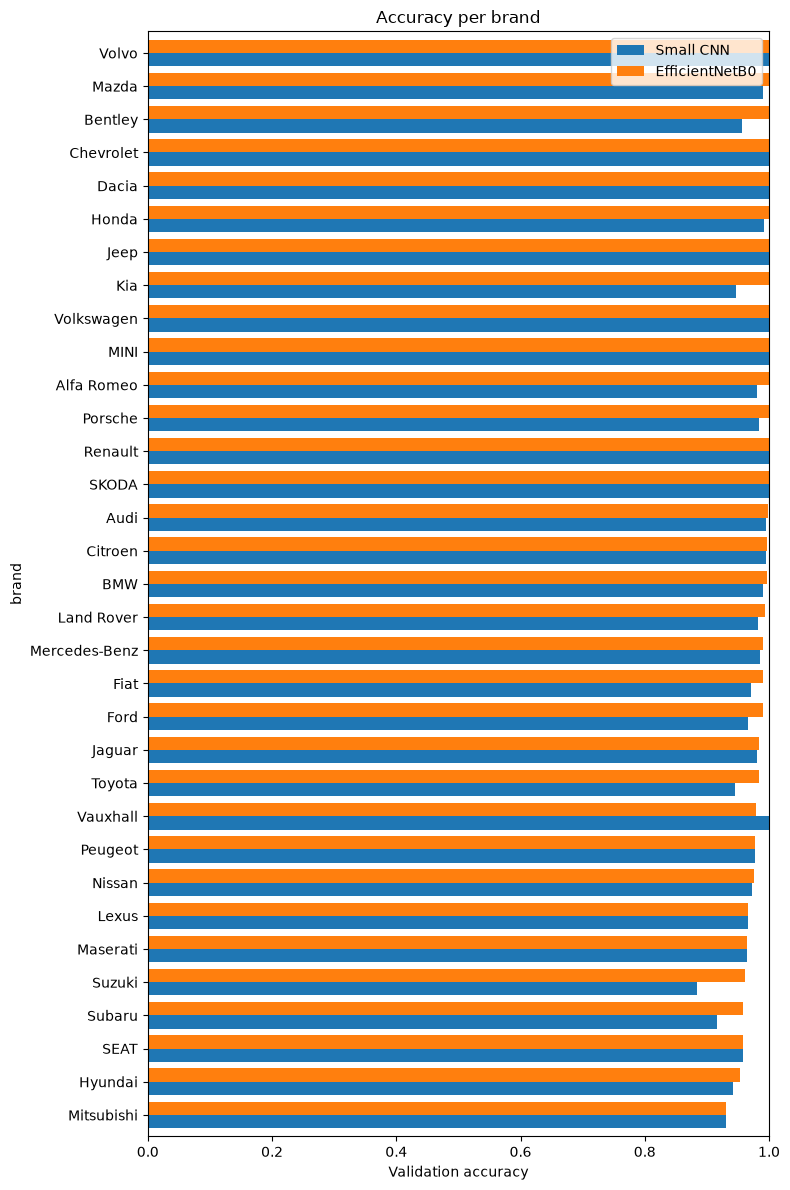

In [14]:
small_cnn = keras.models.load_model(MODELS_DIR / "small_cnn.keras")

candidates = {
    "Small CNN": (small_cnn, IMAGE_SIZE),
    "EfficientNetB0": (effnet, PRETRAINED_IMAGE_SIZE),
}


def evaluate(model, image_size, split):
    """Predict every image of a split and return one row per image."""
    part = df[df["split"] == split].copy()
    part["predicted"] = model.predict(make_dataset(split, image_size), verbose=0).argmax(axis=1)
    part["predicted_brand"] = [class_names[i] for i in part["predicted"]]
    part["correct"] = part["predicted"] == part["label"]
    return part


val_results = {name: evaluate(model, size, "val") for name, (model, size) in candidates.items()}

val_per_brand = pd.DataFrame({name: r.groupby("brand")["correct"].mean() for name, r in val_results.items()})
val_summary = pd.DataFrame({
    "accuracy": {name: r["correct"].mean() for name, r in val_results.items()},
    "balanced accuracy": val_per_brand.mean(),
})
print(val_summary.map("{:.1%}".format).to_string())

ax = val_per_brand.sort_values("EfficientNetB0").plot.barh(figsize=(8, 12), width=0.8)
ax.set_xlim(0, 1)
ax.set_xlabel("Validation accuracy")
ax.set_title("Accuracy per brand")
plt.tight_layout()
plt.show()

### 6.2 Final score on the test set

The test set has not been used for anything so far: not for training, not for early stopping, not for choosing the model. That makes this the honest estimate of how the model does on car photos it has never seen. The predictions are saved to `models/test_predictions.csv`.

In [15]:
final_name = val_summary["balanced accuracy"].idxmax()
final_model, final_size = candidates[final_name]

test = evaluate(final_model, final_size, "test")
test.to_csv(MODELS_DIR / "test_predictions.csv", index=False)

test_per_brand = test.groupby("brand")["correct"].mean().sort_values()
print(f"Final model: {final_name}")
print(f"Test accuracy: {test['correct'].mean():.1%}")
print(f"Test balanced accuracy: {test_per_brand.mean():.1%}")
print(f"\nWeakest brands:\n{test_per_brand.head(5).map('{:.0%}'.format).to_string()}")

mistakes = test[~test["correct"]].groupby(["brand", "predicted_brand"]).size()
print(f"\nMost common mistakes:\n{mistakes.sort_values(ascending=False).head(10).to_string()}")

Final model: EfficientNetB0
Test accuracy: 99.4%
Test balanced accuracy: 98.9%

Weakest brands:
brand
Mitsubishi    95%
Suzuki        96%
Subaru        96%
Lexus         97%
Vauxhall      97%

Most common mistakes:
brand    predicted_brand
Audi     Nissan             1
Toyota   Hyundai            1
Nissan   SKODA              1
         Toyota             1
Peugeot  Kia                1
Subaru   Toyota             1
Suzuki   Mitsubishi         1
Toyota   Citroen            1
         Nissan             1
Audi     Volvo              1


### 6.3 Predict the brand of any photo

`predict_brand` takes the path of a car-front photo and returns the most likely brands. The model outputs one raw score per brand; **softmax** turns those scores into probabilities that add up to 100%.

Below: 12 random test photos, titled with the true brand and the model's top 3 guesses (green when the first guess is right).

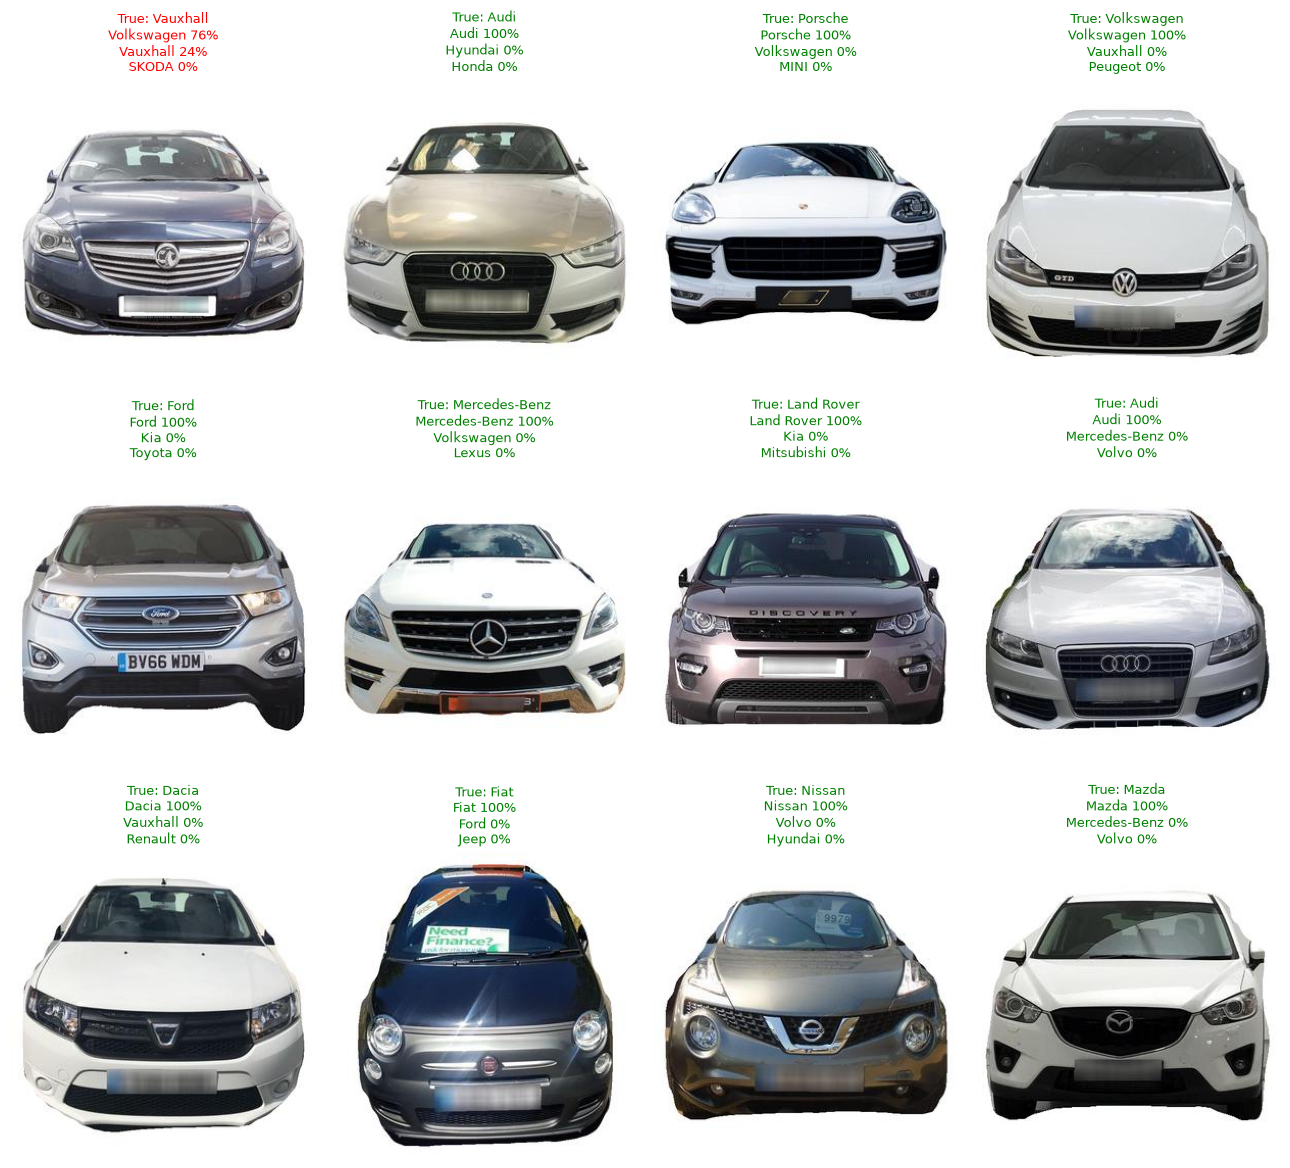

In [16]:
def predict_brand(path, top=3):
    """Return the `top` most likely brands for one photo, with their probabilities."""
    image, _ = load_image(path, 0, final_size)
    scores = final_model.predict(image[None], verbose=0)[0]
    probabilities = tf.nn.softmax(scores).numpy()
    best = probabilities.argsort()[::-1][:top]
    return [(class_names[i], float(probabilities[i])) for i in best]


examples = test.sample(12, random_state=1)

fig, axes = plt.subplots(3, 4, figsize=(13, 12))
for ax, (_, row) in zip(axes.flat, examples.iterrows()):
    guesses = predict_brand(row["path"])
    ax.imshow(Image.open(row["path"]))
    ax.set_title(
        f"True: {row['brand']}\n" + "\n".join(f"{brand} {p:.0%}" for brand, p in guesses),
        fontsize=9,
        color="green" if guesses[0][0] == row["brand"] else "red",
    )
    ax.axis("off")
plt.tight_layout()
plt.show()